In [1]:
!pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sachinkumar413/diabetic-retinopathy-dataset")

print("Path to dataset files:", path)

100%|██████████| 350M/350M [02:21<00:00, 2.59MB/s] 

Extracting files...


Path to dataset files: /Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1


In [2]:
import os
import random

dataset_path = "/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1"

classes = ["Healthy", "Mild DR", "Moderate DR", "Severe DR", "Proliferate DR"]

In [3]:
sample_images = {}
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    files = os.listdir(cls_path)
    random_file = random.choice(files)
    sample_images[cls] = os.path.join(cls_path, random_file)

sample_images

{'Healthy': '/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1/Healthy/Healthy_143.png',
 'Mild DR': '/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1/Mild DR/Mild_DR_177.png',
 'Moderate DR': '/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1/Moderate DR/Moderate_DR_554.png',
 'Severe DR': '/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1/Severe DR/Severe DR_121.png',
 'Proliferate DR': '/Users/samreddyvarunreddy/.cache/kagglehub/datasets/sachinkumar413/diabetic-retinopathy-dataset/versions/1/Proliferate DR/Proliferate DR_146.png'}

In [4]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


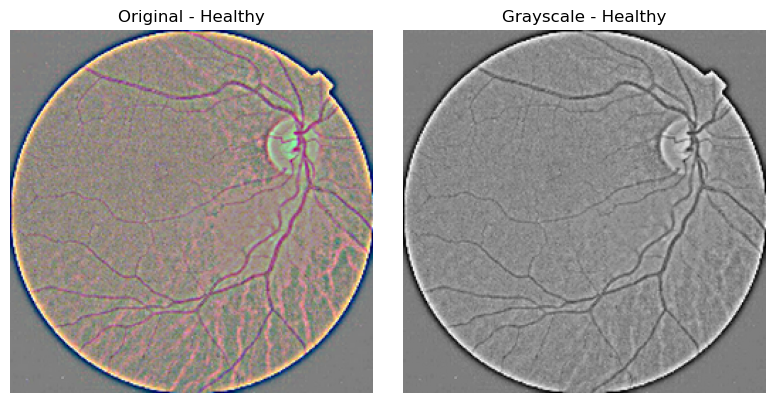

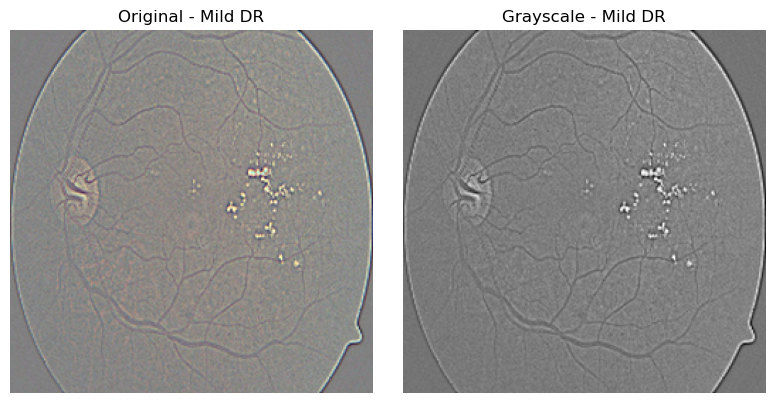

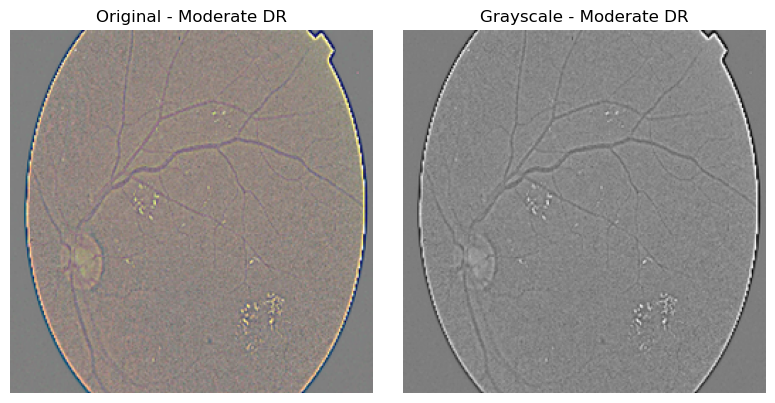

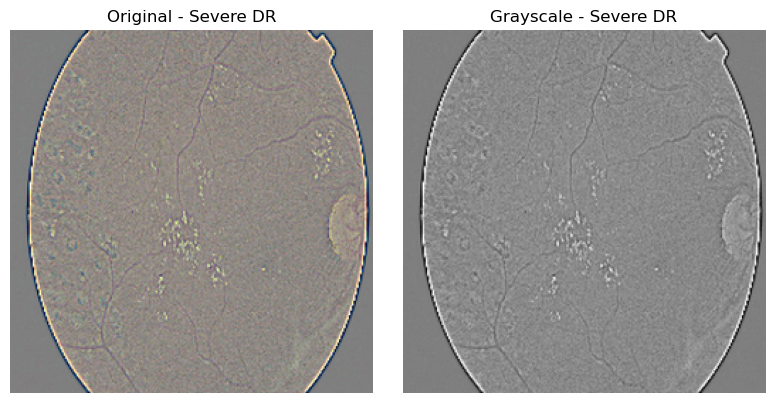

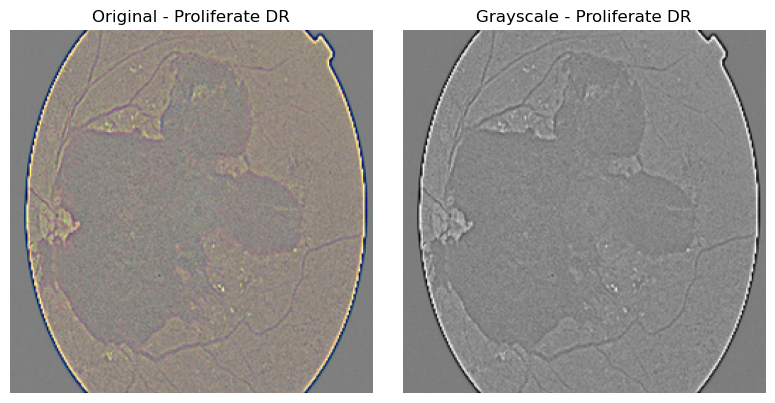

Grayscale image stored for class 'Healthy', shape: (256, 256)
Grayscale image stored for class 'Mild DR', shape: (256, 256)
Grayscale image stored for class 'Moderate DR', shape: (256, 256)
Grayscale image stored for class 'Severe DR', shape: (256, 256)
Grayscale image stored for class 'Proliferate DR', shape: (256, 256)


In [5]:
#If the images are color images, you will convert the color images to grayscale images 
# References :(see https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_rgb_to_gray.html)
import matplotlib.pyplot as plt
from skimage import io
from skimage.color import rgb2gray
images_grayscale = {}
for cls, img_path in sample_images.items():
    original = io.imread(img_path)
    grayscale = rgb2gray(original)
    images_grayscale[cls] = grayscale
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    ax = axes.ravel()
    ax[0].imshow(original)
    ax[0].set_title(f"Original - {cls}")
    ax[0].axis('off')
    ax[1].imshow(grayscale, cmap=plt.cm.gray)
    ax[1].set_title(f"Grayscale - {cls}")
    ax[1].axis('off')
    fig.tight_layout()
    plt.show()
for cls, gray_img in images_grayscale.items():
    print(f"Grayscale image stored for class '{cls}', shape: {gray_img.shape}")

In [6]:
import numpy as np
from skimage import filters
def angle(dx, dy):
    #"""Calculate the angles between horizontal and vertical operators."""
    return np.mod(np.arctan2(dy, dx), np.pi)
images_angle = {}
for cls, I in images_grayscale.items():
    dx = filters.sobel_h(I)
    dy = filters.sobel_v(I)
    angle_sobel = angle(dx, dy)
    images_angle[cls] = angle_sobel
for cls, angle_img in images_angle.items():
    print(f"Angle image stored for class '{cls}', shape: {angle_img.shape}")
    #print(angle_img)

Angle image stored for class 'Healthy', shape: (256, 256)
Angle image stored for class 'Mild DR', shape: (256, 256)
Angle image stored for class 'Moderate DR', shape: (256, 256)
Angle image stored for class 'Severe DR', shape: (256, 256)
Angle image stored for class 'Proliferate DR', shape: (256, 256)


In [7]:
# Use skimage.exposure.histogram (see https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.histogram) to obtain histograms with 36 bins.
from skimage import exposure
histograms = {}
for cls, angle_img in images_angle.items():
    hist, bin_centers = exposure.histogram(angle_img, nbins=36)
    histograms[cls] = (hist, bin_centers)
    print(f"Class '{cls}':")
    print("Histogram counts:", hist)
    print("Bin centers:", bin_centers)
    print("\n")

Class 'Healthy':
Histogram counts: [2382 1715 1819 1796 1744 1786 1762 1804 1778 2116 1770 1832 1884 1736
 1863 1803 1800 1778 2154 1698 1748 1876 1736 1769 1813 1719 1724 1989
 1762 1771 1793 1711 1768 1760 1764 1813]
Bin centers: [0.04363323 0.13089969 0.21816616 0.30543262 0.39269908 0.47996554
 0.56723201 0.65449847 0.74176493 0.82903139 0.91629786 1.00356432
 1.09083078 1.17809725 1.26536371 1.35263017 1.43989663 1.5271631
 1.61442956 1.70169602 1.78896248 1.87622895 1.96349541 2.05076187
 2.13802833 2.2252948  2.31256126 2.39982772 2.48709418 2.57436065
 2.66162711 2.74889357 2.83616003 2.9234265  3.01069296 3.09795942]


Class 'Mild DR':
Histogram counts: [1684 1693 1647 1617 1693 1681 1642 1744 1709 1789 1860 1917 1908 1894
 1916 1947 1962 2117 2027 2053 2000 1979 1877 1980 1885 1860 1843 1761
 1753 1720 1750 1663 1741 1728 1765 1731]
Bin centers: [0.04382384 0.13108469 0.21834555 0.30560641 0.39286726 0.48012812
 0.56738897 0.65464983 0.74191068 0.82917154 0.91643239 1.0036932

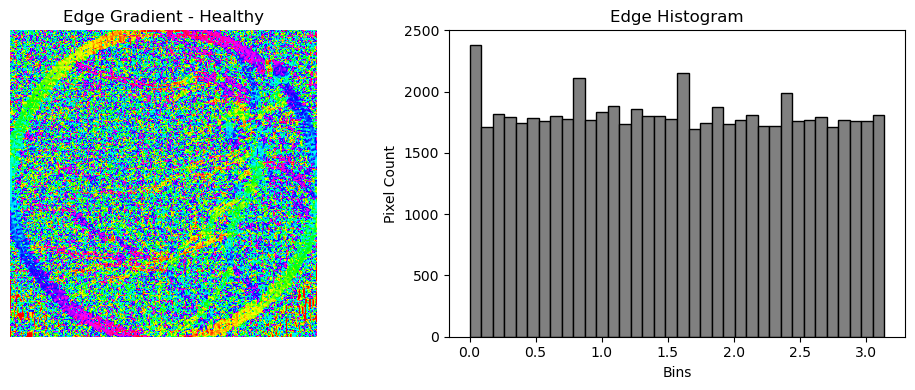

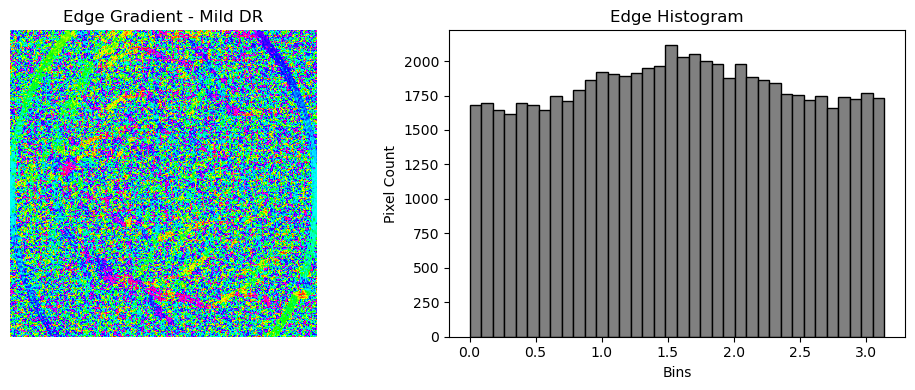

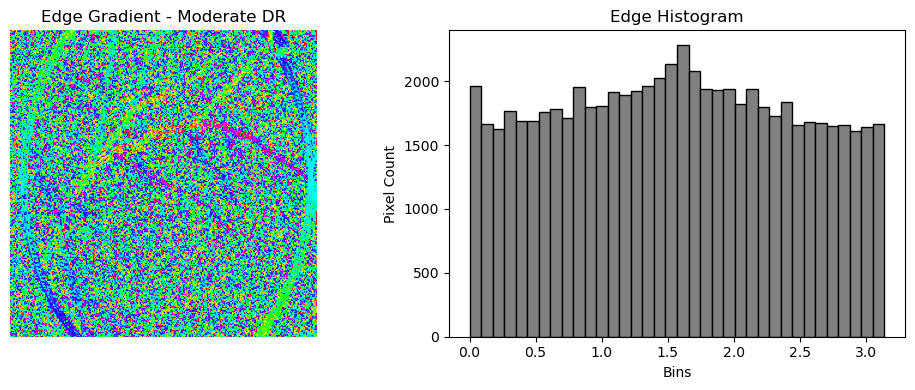

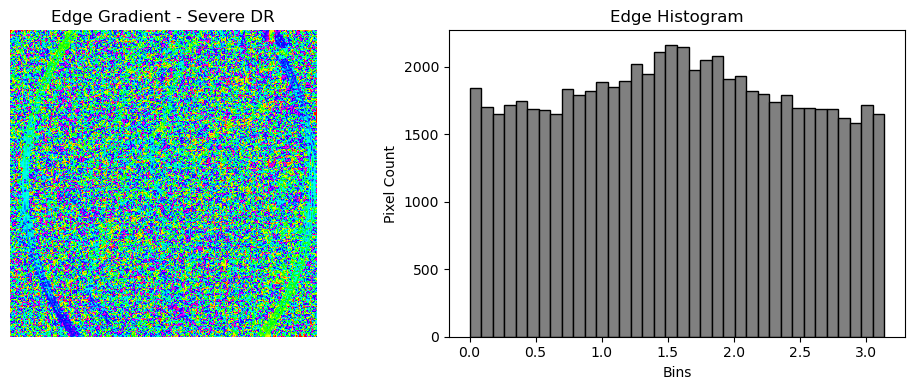

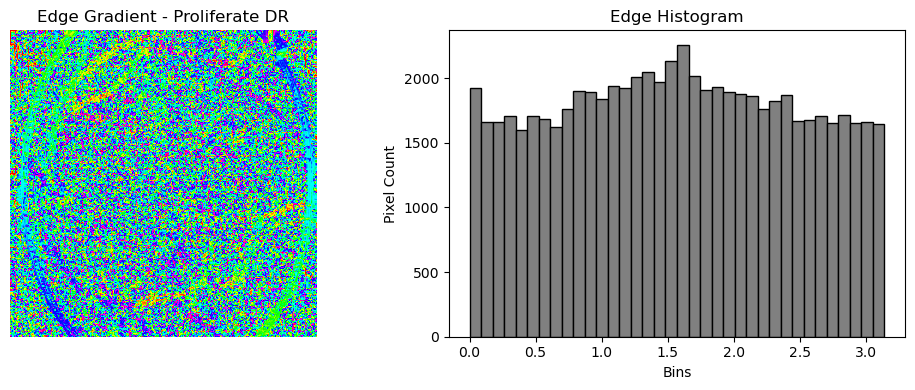

In [8]:
import matplotlib.pyplot as plt
from skimage import exposure

for cls, angle_img in images_angle.items():
    hist, bin_centers = exposure.histogram(angle_img, nbins=36)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes.ravel()
    ax[0].imshow(angle_img, cmap='hsv')
    ax[0].set_title(f"Edge Gradient - {cls}")
    ax[0].axis('off')
    ax[1].bar(bin_centers, hist, width=bin_centers[1]-bin_centers[0], color='gray', edgecolor='black')
    ax[1].set_title("Edge Histogram")
    ax[1].set_xlabel("Bins")
    ax[1].set_ylabel("Pixel Count")
    fig.tight_layout()
    plt.show()



In [9]:
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html#sklearn.metrics.pairwise.distance_metrics
from sklearn.metrics.pairwise import euclidean_distances, manhattan_distances, cosine_distances

hist1, bins1 = histograms['Healthy']
hist2, bins2 = histograms['Mild DR']
hist1 = hist1.reshape(1, -1)
hist2 = hist2.reshape(1, -1)
# Euclidean distance
euclidean = euclidean_distances(hist1, hist2)[0][0]
# Manhattan distance
manhattan = manhattan_distances(hist1, hist2)[0][0]
# Cosine distance
cosine = cosine_distances(hist1, hist2)[0][0]

print("Histogram Comparison Between 'Healthy' and 'Mild DR':")
print(f"Euclidean Distance: {euclidean:.4f}")
print(f"Manhattan Distance: {manhattan:.4f}")
print(f"Cosine Distance: {cosine:.4f}")



Histogram Comparison Between 'Healthy' and 'Mild DR':
Euclidean Distance: 1133.7531
Manhattan Distance: 4900.0000
Cosine Distance: 0.0054


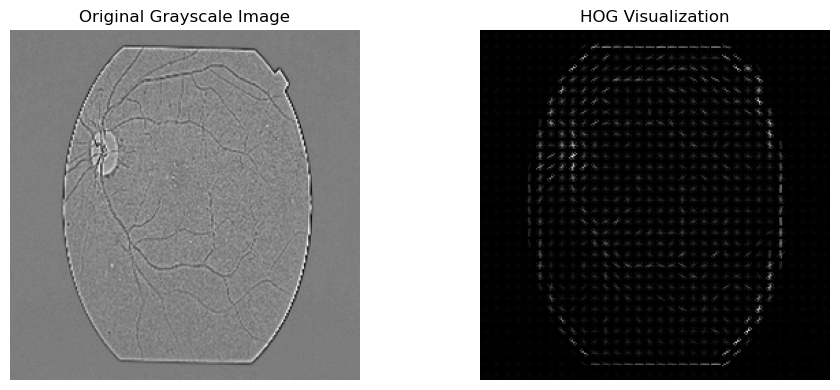

HOG feature vector length: 34596


In [31]:
#Histogram of Oriented Gradient (HOG) feature descriptor
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.feature import hog
image = images_grayscale['Mild DR']
hog_features, hog_image = hog(image,orientations=9,pixels_per_cell=(8, 8),cells_per_block=(2, 2),block_norm='L2-Hys',visualize=True,channel_axis=None)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes.ravel()
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original Grayscale Image")
ax[0].axis('off')
ax[1].imshow(hog_image, cmap=plt.cm.gray)
ax[1].set_title("HOG Visualization")
ax[1].axis('off')
plt.tight_layout()
plt.show()

print(f"HOG feature vector length: {len(hog_features)}")


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, exposure, color
from skimage.color import rgb2gray
from sklearn.decomposition import PCA

In [11]:
# Q4 step (b)
all_histograms = []
all_labels = []
for cls in classes:
    cls_path = os.path.join(dataset_path, cls)
    files = os.listdir(cls_path)
    for file in files:
        img = io.imread(os.path.join(cls_path, file))
        gray = rgb2gray(img)
        dx = filters.sobel_h(gray)
        dy = filters.sobel_v(gray)
        angle_sobel = np.mod(np.arctan2(dy, dx), np.pi)
        hist, bins = exposure.histogram(angle_sobel, nbins=36)
        all_histograms.append(hist)
        all_labels.append(cls)

X = np.array(all_histograms)  # shape = (num_images, 36)
y = np.array(all_labels)      # shape = (num_images,)

In [12]:
#Perform Principal Component Analysis (PCA) dimensionality reduction on the set of histograms to reduce from 36 to 2 dimensions.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Shape after PCA:", X_pca.shape)

Shape after PCA: (2750, 2)


In [13]:
print(X_pca[:10])

[[25227.03556945   -76.58298702]
 [21597.26775135   155.81748051]
 [25223.97933132  -255.35378054]
 [21692.72000252   271.05361674]
 [-2134.32271409  -657.75299613]
 [-3499.49593463  -343.94857187]
 [-2065.4710735   -786.79641784]
 [-2248.99731924  -448.35244819]
 [-3531.00221465  -445.93651077]
 [ 2321.19883363  1097.3827899 ]]


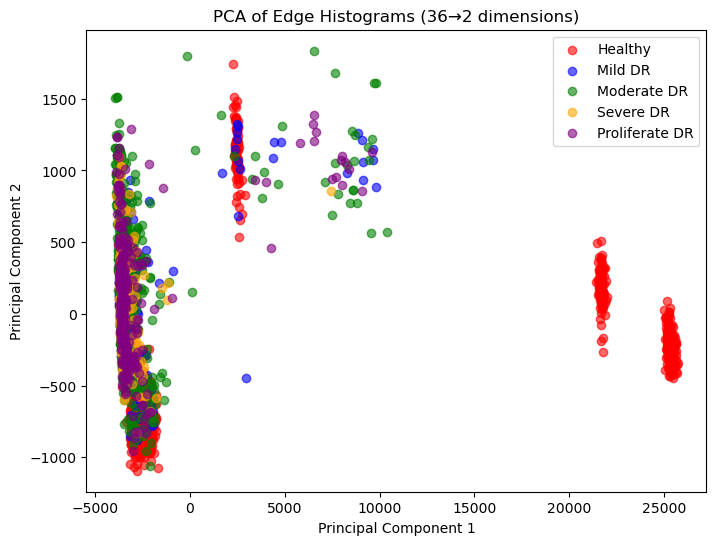

In [15]:
#Plot the 2D points using four different colors for data from the four classes
# Assign colors to classes
colors = {"Healthy": "red", "Mild DR": "blue", "Moderate DR": "green", "Severe DR": "orange","Proliferate DR":"purple"}

plt.figure(figsize=(8, 6))
for cls in classes:
    idx = (y == cls)
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], c=colors[cls], label=cls, alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Edge Histograms (36→2 dimensions)")
plt.legend()
plt.show()


As per the above plot, only the class "healthy" is visually seperable.